In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ydata_profiling import ProfileReport

In [2]:
#set plot formatting to seaborn's default
sns.set() 

In [3]:
%matplotlib inline

# Loading the cleaned Spotify dataset

In [4]:
df = pd.read_csv('..\Data\spotify_songs_cleaned.csv')
df.head().T

,0,1,2,3,4
track_name,Dance Monkey,ROXANNE,Blinding Lights,Circles,Tusa
track_artist,Tones and I,Arizona Zervas,The Weeknd,Post Malone,KAROL G
track_popularity,100,99,98,98,98
track_album_name,Dance Monkey (Stripped Back) / Dance Monkey,ROXANNE,Blinding Lights,Hollywood's Bleeding,Tusa
track_album_release_date,2019-10-17,2019-10-10,2019-11-29,2019-09-06,2019-11-07
danceability,0.824,0.621,0.513,0.695,0.803
energy,0.588,0.601,0.796,0.762,0.715
key,6,6,1,0,2
loudness,-6.4,-5.616,-4.075,-3.497,-3.28
mode,0,0,1,1,1


In [5]:
df.shape

(24532, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24532 entries, 0 to 24531
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                24532 non-null  object 
 1   track_artist              24532 non-null  object 
 2   track_popularity          24532 non-null  int64  
 3   track_album_name          24532 non-null  object 
 4   track_album_release_date  24532 non-null  object 
 5   danceability              24532 non-null  float64
 6   energy                    24532 non-null  float64
 7   key                       24532 non-null  int64  
 8   loudness                  24532 non-null  float64
 9   mode                      24532 non-null  int64  
 10  speechiness               24532 non-null  float64
 11  acousticness              24532 non-null  float64
 12  instrumentalness          24532 non-null  float64
 13  liveness                  24532 non-null  float64
 14  valenc

# Data Profile using ydata-profiling
##### Provides many EDA functions from one line of code. See the github documentation [here](https://github.com/ydataai/ydata-profiling/blob/develop/README.md)

In [7]:
#Save to HTML file
#Showing in iframe did not work when uploaded to Github so I have commented it out
profile = ProfileReport(df, title="Profiling Report")
profile.to_file("spotify ydata-profiling.html")
#profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:00<00:00, 48.51it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Observations:
##### The data spans 63 years with 27.3% of the tracks coming from 2019
##### Track Popularity appears normally distributed but there are zeroes for 2081 songs (8.5% of songs) 
##### Track Popularity mean = 40.727458 and standard deviation = 23.246349
##### 27% of songs are from 2019. This is the latest year where data is available.
##### High postive correlation between energy and loudness 
##### High negative correlation between energy and acousticness
##### mode and key are discrete values which should be treated as categories

# Top Tracks
#### There is only one track with popularity of 100: [Dance Monkey](https://youtu.be/q0hyYWKXF0Q?si=_QYZ9s0InbXCEuFk)

In [8]:
# Calculate the 99th percentile threshold
threshold = df['track_popularity'].quantile(0.99)

# Subset to top 1% songs
top_tracks = df.loc[df['track_popularity'] >= threshold, :]
top_tracks

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,danceability,energy,key,loudness,mode,...,liveness,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences,release_year,release_month,release_day
0,Dance Monkey,Tones and I,100,Dance Monkey (Stripped Back) / Dance Monkey,2019-10-17,0.824,0.588,6,-6.400,0,...,0.1490,0.513,98.027,209438,latin,latin hip hop,2,2019,10,17
1,ROXANNE,Arizona Zervas,99,ROXANNE,2019-10-10,0.621,0.601,6,-5.616,0,...,0.4600,0.457,116.735,163636,r&b,hip pop,4,2019,10,10
2,Blinding Lights,The Weeknd,98,Blinding Lights,2019-11-29,0.513,0.796,1,-4.075,1,...,0.0938,0.345,171.017,201573,pop,dance pop,8,2019,11,29
3,Circles,Post Malone,98,Hollywood's Bleeding,2019-09-06,0.695,0.762,0,-3.497,1,...,0.0863,0.553,120.042,215280,latin,hip pop,5,2019,9,6
4,Tusa,KAROL G,98,Tusa,2019-11-07,0.803,0.715,2,-3.280,1,...,0.0574,0.574,101.085,200960,latin,dance pop,7,2019,11,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,So Am I,Ava Max,83,So Am I,2019-03-07,0.682,0.656,6,-4.670,1,...,0.3530,0.607,130.089,183027,pop,dance pop,3,2019,3,7
259,Stressed Out,Twenty One Pilots,83,Blurryface,2015-05-15,0.734,0.637,4,-5.677,0,...,0.0602,0.648,169.977,202333,pop,electropop,5,2015,5,15
260,ZEZE,Kodak Black,83,Dying to Live,2018-12-14,0.861,0.603,8,-5.788,0,...,0.0924,0.504,98.043,228760,pop,hip hop,3,2018,12,14
261,i'm so tired...,Lauv,83,i'm so tired...,2019-01-24,0.599,0.733,11,-7.058,1,...,0.2420,0.534,102.211,162583,pop,electropop,1,2019,1,24


In [9]:
features = ['track_popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'release_year']

In [10]:
top_tracks[features].agg(['mean', 'median', 'std'])

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_year
mean,86.555133,0.694711,0.623601,5.444867,-6.134023,0.547529,0.127112,0.238781,0.010158,0.169899,0.491914,121.785935,203081.117871,2016.954373
median,85.000000,0.711000,0.642000,6.000000,-5.749000,1.000000,0.077300,0.149000,0.000000,0.122000,0.494000,117.401000,200742.000000,2019.000000
std,3.839803,0.127845,0.166553,3.576295,2.717980,0.498685,0.112827,0.246317,0.058396,0.133045,0.222368,29.709701,37465.621101,6.950054


In [11]:
#The top tracks have more recent release years. This makes sense as listeners' tastes change and new tracks take mind share. 
#I will plot these numbers along with the ECDF later to visualize the top tracks in relation to other songs.

# Top Artists

In [12]:
# Most popular artists which have at least 2 tracks in the dataset
top_artists = (
    top_tracks.groupby("track_artist")
    .agg(mean_popularity=("track_popularity", "mean"), track_count=("track_popularity", "count"))
    .query("track_count >= 2")
    .sort_values("mean_popularity", ascending=False)
    .head(10)
    
)
top_artists.reset_index(drop=False, inplace=True)
top_artists.index = range(1, len(top_artists)+1)

top_artists

,track_artist,mean_popularity,track_count
1,Tones and I,92.000000,2
2,Dua Lipa,90.000000,2
3,Lewis Capaldi,90.000000,3
4,Harry Styles,89.666667,3
5,The Weeknd,89.500000,4
6,MEDUZA,89.500000,2
7,Travis Scott,89.000000,3
8,Sam Smith,89.000000,2
9,Selena Gomez,89.000000,3
10,Bad Bunny,88.666667,3


In [13]:
# Artists with the most tracks
count_artists = (
    top_tracks.groupby("track_artist")
    .agg(track_count=("track_popularity", "count"), mean_popularity=("track_popularity", "mean"))
    .sort_values("track_count", ascending=False)
    .head(10)
)
count_artists.reset_index(drop=False, inplace=True)
count_artists.index = range(1, len(top_artists)+1)

count_artists

,track_artist,track_count,mean_popularity
1,Billie Eilish,11,87.181818
2,Post Malone,8,88.125000
3,Ed Sheeran,7,87.000000
4,Juice WRLD,6,87.500000
5,Ariana Grande,5,85.600000
6,The Weeknd,4,89.500000
7,XXXTENTACION,4,85.750000
8,The Chainsmokers,4,84.500000
9,Lauv,4,83.750000
10,DaBaby,4,88.500000


# Empirical Cumulative Distribution Function (ECDF)

In [14]:
def ecdf(data):
    """Compute ECDF for a one-dimensional array of measurements."""
    # Number of data points: n
    n = len(data)

    # x-data for the ECDF: x
    x = np.sort(data)

    # y-data for the ECDF: y
    y = np.arange(1, n+1) / n

    return x, y

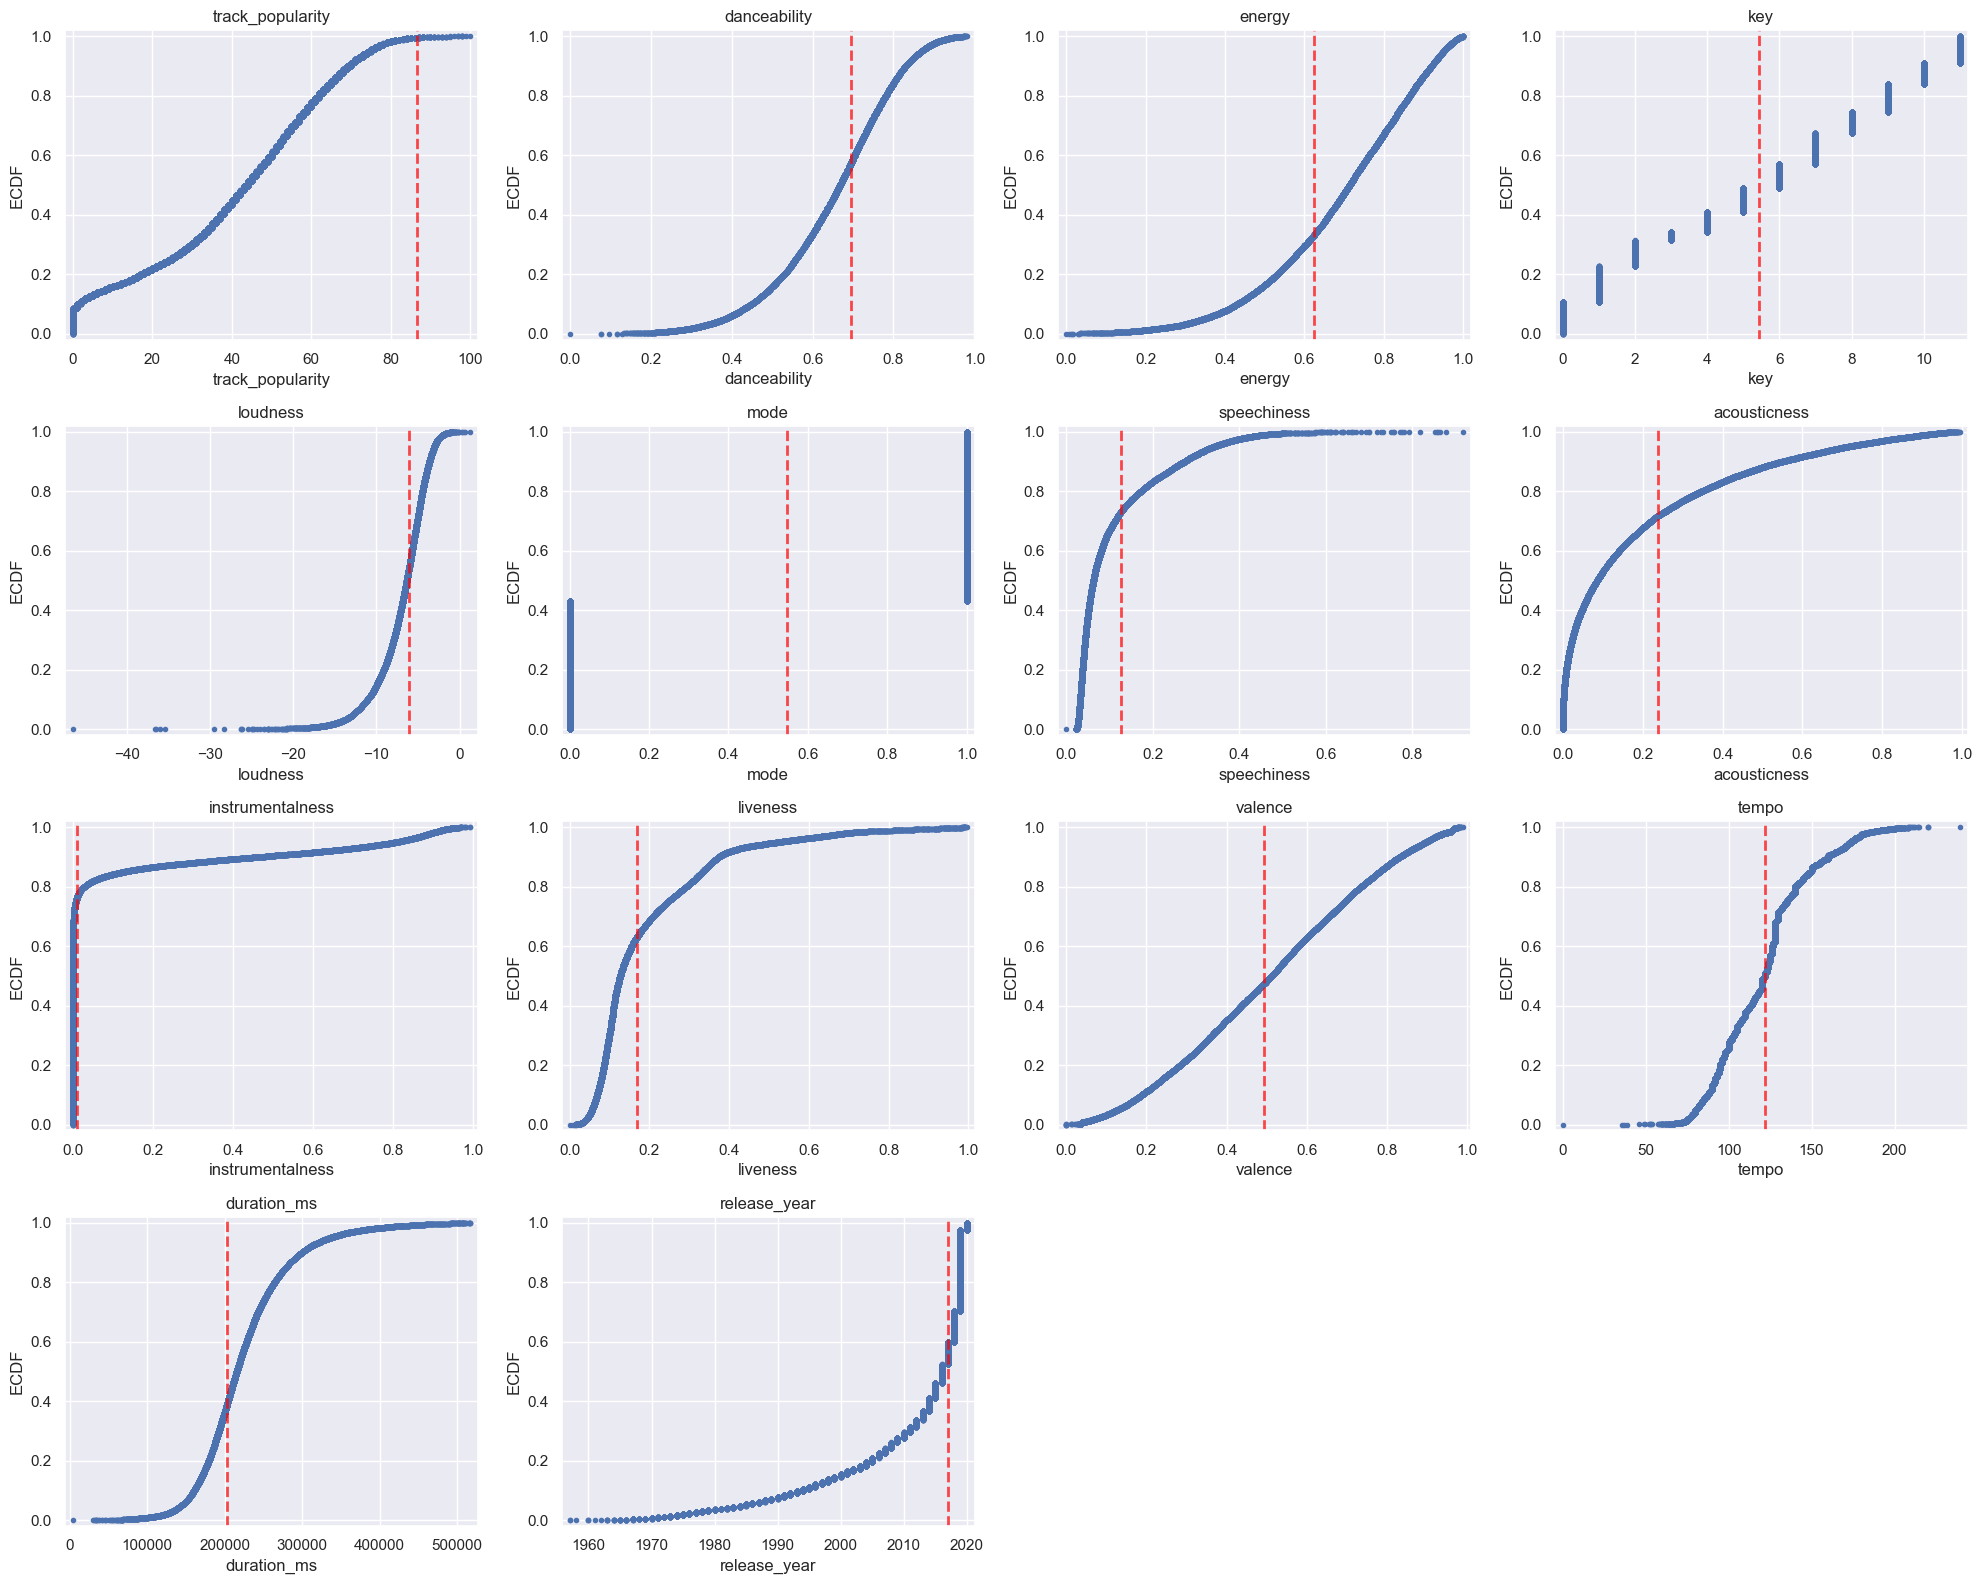

In [15]:
n_features = len(features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()  # flatten to easily iterate

for i, feature in enumerate(features):
    x, y = ecdf(df[feature])
    axes[i].plot(x, y, marker='.', linestyle='none')
    axes[i].set_title(feature)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('ECDF')
    axes[i].margins(0.02)
    
    # Add vertical line at mean for top 1% of tracks
    mean_val = top_tracks[feature].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, linewidth=2)

# Hide unused subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The top songs have some features which are in higher percentile than peers: 
<br> --danceability around the 60th percentile
<br> --speechiness around the 75th percentile
<br> --acousticness around the 70th percentile
<br> --liveness around the 60th percentile
<br><br>Lower percentile than peers:
<br> --energy is around the 30th percentile

<br>Other observations:
<br>--instrumentalness has very small values in most songs as seen by the sharp rise
<br>--valence across songs is more evenly distributed

# Keys

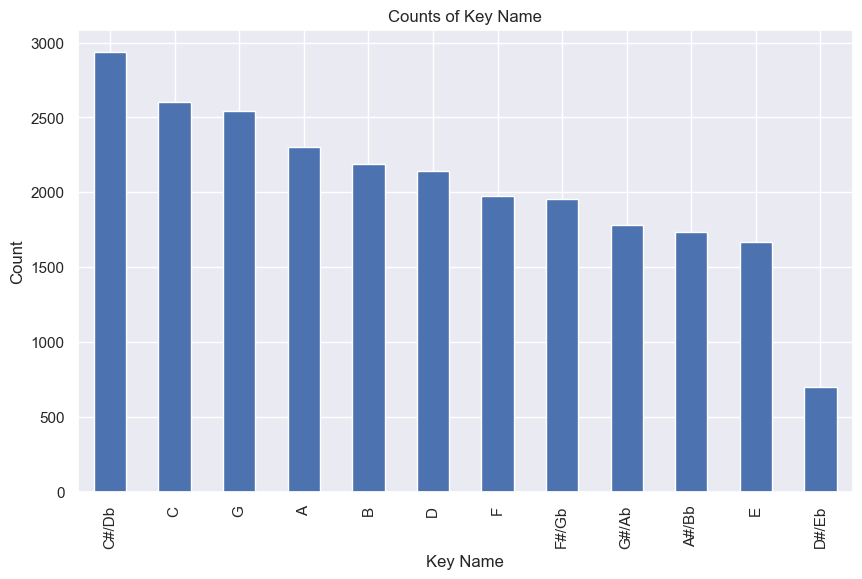

In [16]:
# Bar chart of 'keys' to get a better look at it
# C#/Db key is the most used
# D#/Eb key is the least used

mapping = {0:'C', 1:'C#/Db', 2:'D', 3:'D#/Eb', 4:'E', 5:'F', 6:'F#/Gb', 7:'G', 8:'G#/Ab', 9:'A', 10:'A#/Bb', 11:'B'}
df['key_name'] = df['key'].map(mapping)

df['key_name'].value_counts().plot(kind='bar', figsize=(10,6))

plt.xlabel("Key Name")
plt.ylabel("Count")
plt.title("Counts of Key Name")
plt.show()

In [17]:
# Based on the means,'key' does not appear to have a large impact on popularity
df.groupby('key_name')['track_popularity'].agg(['mean', 'std'])

,mean,std
key_name,,
A,40.722729,23.384881
A#/Bb,40.399308,23.344390
B,40.179827,23.341725
C,41.652074,23.001435
C#/Db,41.066031,23.387217
D,40.096639,23.215991
D#/Eb,40.286533,22.977211
E,40.382494,23.688059
F,40.989378,23.441338


# Danceability

In [18]:
# Examine some tracks with lowest danceability
# I listened to several of these and confirmed the low value is valid (e.g. metal, nature sounds)
df_dance = df.sort_values("danceability", ascending=True)
df_dance.head(10)

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,danceability,energy,key,loudness,mode,...,valence,tempo,duration_ms,top_genre,top_subgenre,track_occurences,release_year,release_month,release_day,key_name
22631,"Hi, How're You Doin'?",DREAMS COME TRUE,0,Dreams Come True,1989-03-21,0.0000,0.315000,1,-26.087,1,...,0.00000,0.000,4000,rock,album rock,1,1989,3,21,C#/Db
1238,Forest Rain,Rain Recordings,75,Peaceful Rain Recordings,2019-09-06,0.0771,1.000000,3,-16.540,0,...,0.00001,171.623,170000,latin,tropical,1,2019,9,6,D#/Eb
8679,Relaxing Crickets And Waterfall,Natural Sound Makers,52,Forest By Night,2017-01-09,0.0787,0.000175,7,-35.960,1,...,0.01160,169.062,264154,latin,tropical,1,2017,1,9,G
16057,SILHOUETTE,Lorn,34,REMNANT,2018-09-05,0.0985,0.095800,1,-18.209,0,...,0.02760,87.920,233275,pop,electropop,1,2018,9,5,C#/Db
12668,Feed The Machine,Red,43,Until We Have Faces,2011-02-01,0.1160,0.948000,9,-4.600,1,...,0.03960,172.052,310920,rock,hard rock,1,2011,2,1,A
19542,stakra,Ryuichi Sakamoto,18,async,2017-04-28,0.1180,0.404000,4,-16.686,0,...,0.22800,86.959,221192,pop,electropop,1,2017,4,28,E
7273,Hardwired,Metallica,56,Hardwired…To Self-Destruct,2016-11-18,0.1300,0.991000,11,-3.126,1,...,0.50500,185.364,191332,rock,hard rock,1,2016,11,18,B
3982,Caribbean Thunderstorm,Mother Nature Sound FX,65,Thunderstorms,2017-01-09,0.1350,0.723000,8,-22.636,1,...,0.01590,141.159,222469,latin,tropical,1,2017,1,9,G#/Ab
16396,Somewhere Tonight,Beach House,33,Thank Your Lucky Stars,2015-10-16,0.1350,0.312000,7,-11.607,1,...,0.08270,173.782,253960,pop,indie poptimism,1,2015,10,16,G
11508,Creep - The Four Performance,VINCINT,45,Creep (The Four Performance),2018-02-09,0.1400,0.691000,10,-5.524,1,...,0.15500,178.912,218131,r&b,urban contemporary,1,2018,2,9,A#/Bb


# Loudness

In [19]:
# Lowest loudness are nature/relaxation/sleeping tracks
df_loud = df.sort_values("loudness", ascending=True)
df_loud.head(5).T

,9136,12126,7986,8679,9801
track_name,Peaceful Forest,The Sound Of The Jungle With Coloured Birds Fo...,Tropical Forest,Relaxing Crickets And Waterfall,Tropical Rainforest at Dawn 6
track_artist,The Sleep Specialist,Life Sounds Nature,The Sleep Specialist,Natural Sound Makers,Nature Sounds
track_popularity,51,44,54,52,50
track_album_name,Jungle And Forest Sounds,"The Very Best Sound Of Nature - Birds, Waves, ...",Jungle And Forest Sounds,Forest By Night,"Nature Sounds with Birdsong, Waves, Forest, Ga..."
track_album_release_date,2017-01-09,2015-04-01,2017-01-09,2017-01-09,2015-04-17
danceability,0.211,0.226,0.311,0.0787,0.318
energy,0.425,0.442,0.377,0.000175,0.179
key,7,11,3,7,8
loudness,-46.448,-36.624,-36.509,-35.96,-35.427
mode,0,0,0,1,1


# Duration 

In [20]:
# Shortest songs
df['duration_min'] = df['duration_ms']/1000/60
df['duration_sec'] = df['duration_ms']/1000
df_dur = df.sort_values("duration_min", ascending=True)
df_dur.head(5).T

,22631,22540,20336,19538,19886
track_name,"Hi, How're You Doin'?",The Screwed Up Click,The Reddish Flower,Poison (Interlude),This Is the End
track_artist,DREAMS COME TRUE,DJ Screw & The Screwed Up Click,Rob Stepwart,Tetengo,Tetengo
track_popularity,0,0,13,18,16
track_album_name,Dreams Come True,Fallen Soldiers,Trip Stories,Electroshow,Electroshow
track_album_release_date,1989-03-21,2008-02-12,2018-11-27,2018-06-21,2018-06-21
danceability,0.0,0.514,0.767,0.8,0.778
energy,0.315,0.72,0.912,0.588,0.789
key,1,1,6,7,0
loudness,-26.087,-8.507,-9.466,-7.24,-7.946
mode,1,1,1,1,1


In [21]:
# Longest songs
df_dur = df.sort_values("duration_min", ascending=False)
df_dur.head(5).T

,4417,1585,17594,10521,20002
track_name,Kashmir - 2012 Remaster,American Pie,Jam On It (Re-Recorded Version),Roundabout - 2008 Remaster,Come as You Are
track_artist,Led Zeppelin,Don McLean,Newcleus,Yes,V-Sag
track_popularity,63,73,28,48,15
track_album_name,Physical Graffiti (Deluxe Edition),American Pie,Jam On It (Re-Recorded Version),Fragile,Solitude
track_album_release_date,1975-02-24,1971-09-01,2009-01-01,1971-11-26,2020-01-06
danceability,0.483,0.531,0.875,0.411,0.739
energy,0.615,0.481,0.785,0.845,0.68
key,2,4,1,4,0
loudness,-8.538,-11.709,-5.933,-6.821,-7.823
mode,1,0,0,0,1


# Find tracks with multiple zero values features

In [22]:
#remove key and mode from the features becuase these zeros are expected values
features = ['track_popularity', 'danceability', 'energy', 'loudness', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'release_year']

zero_mask = (df[features] == 0)
zero_counts = zero_mask.sum(axis=1)
tracks_with_multi_zeros = df[zero_counts >= 3]
tracks_with_multi_zeros.head(10).T

,22631
track_name,"Hi, How're You Doin'?"
track_artist,DREAMS COME TRUE
track_popularity,0
track_album_name,Dreams Come True
track_album_release_date,1989-03-21
danceability,0.0
energy,0.315
key,1
loudness,-26.087
mode,1


In [23]:
# "Hi, How're You Doin'?" is only 4 seconds long and zeros across multiple features. I believe something is wrong with this track data so I will drop it.

In [24]:
original_rows = len(df)
print("Original records:", original_rows)

df_cleaned = df[df['track_name'] != "Hi, How're You Doin'?"]

new_rows = len(df_cleaned)
print("New records:", new_rows)

Original records: 24532
New records: 24531


# Scatterplots of Popularity

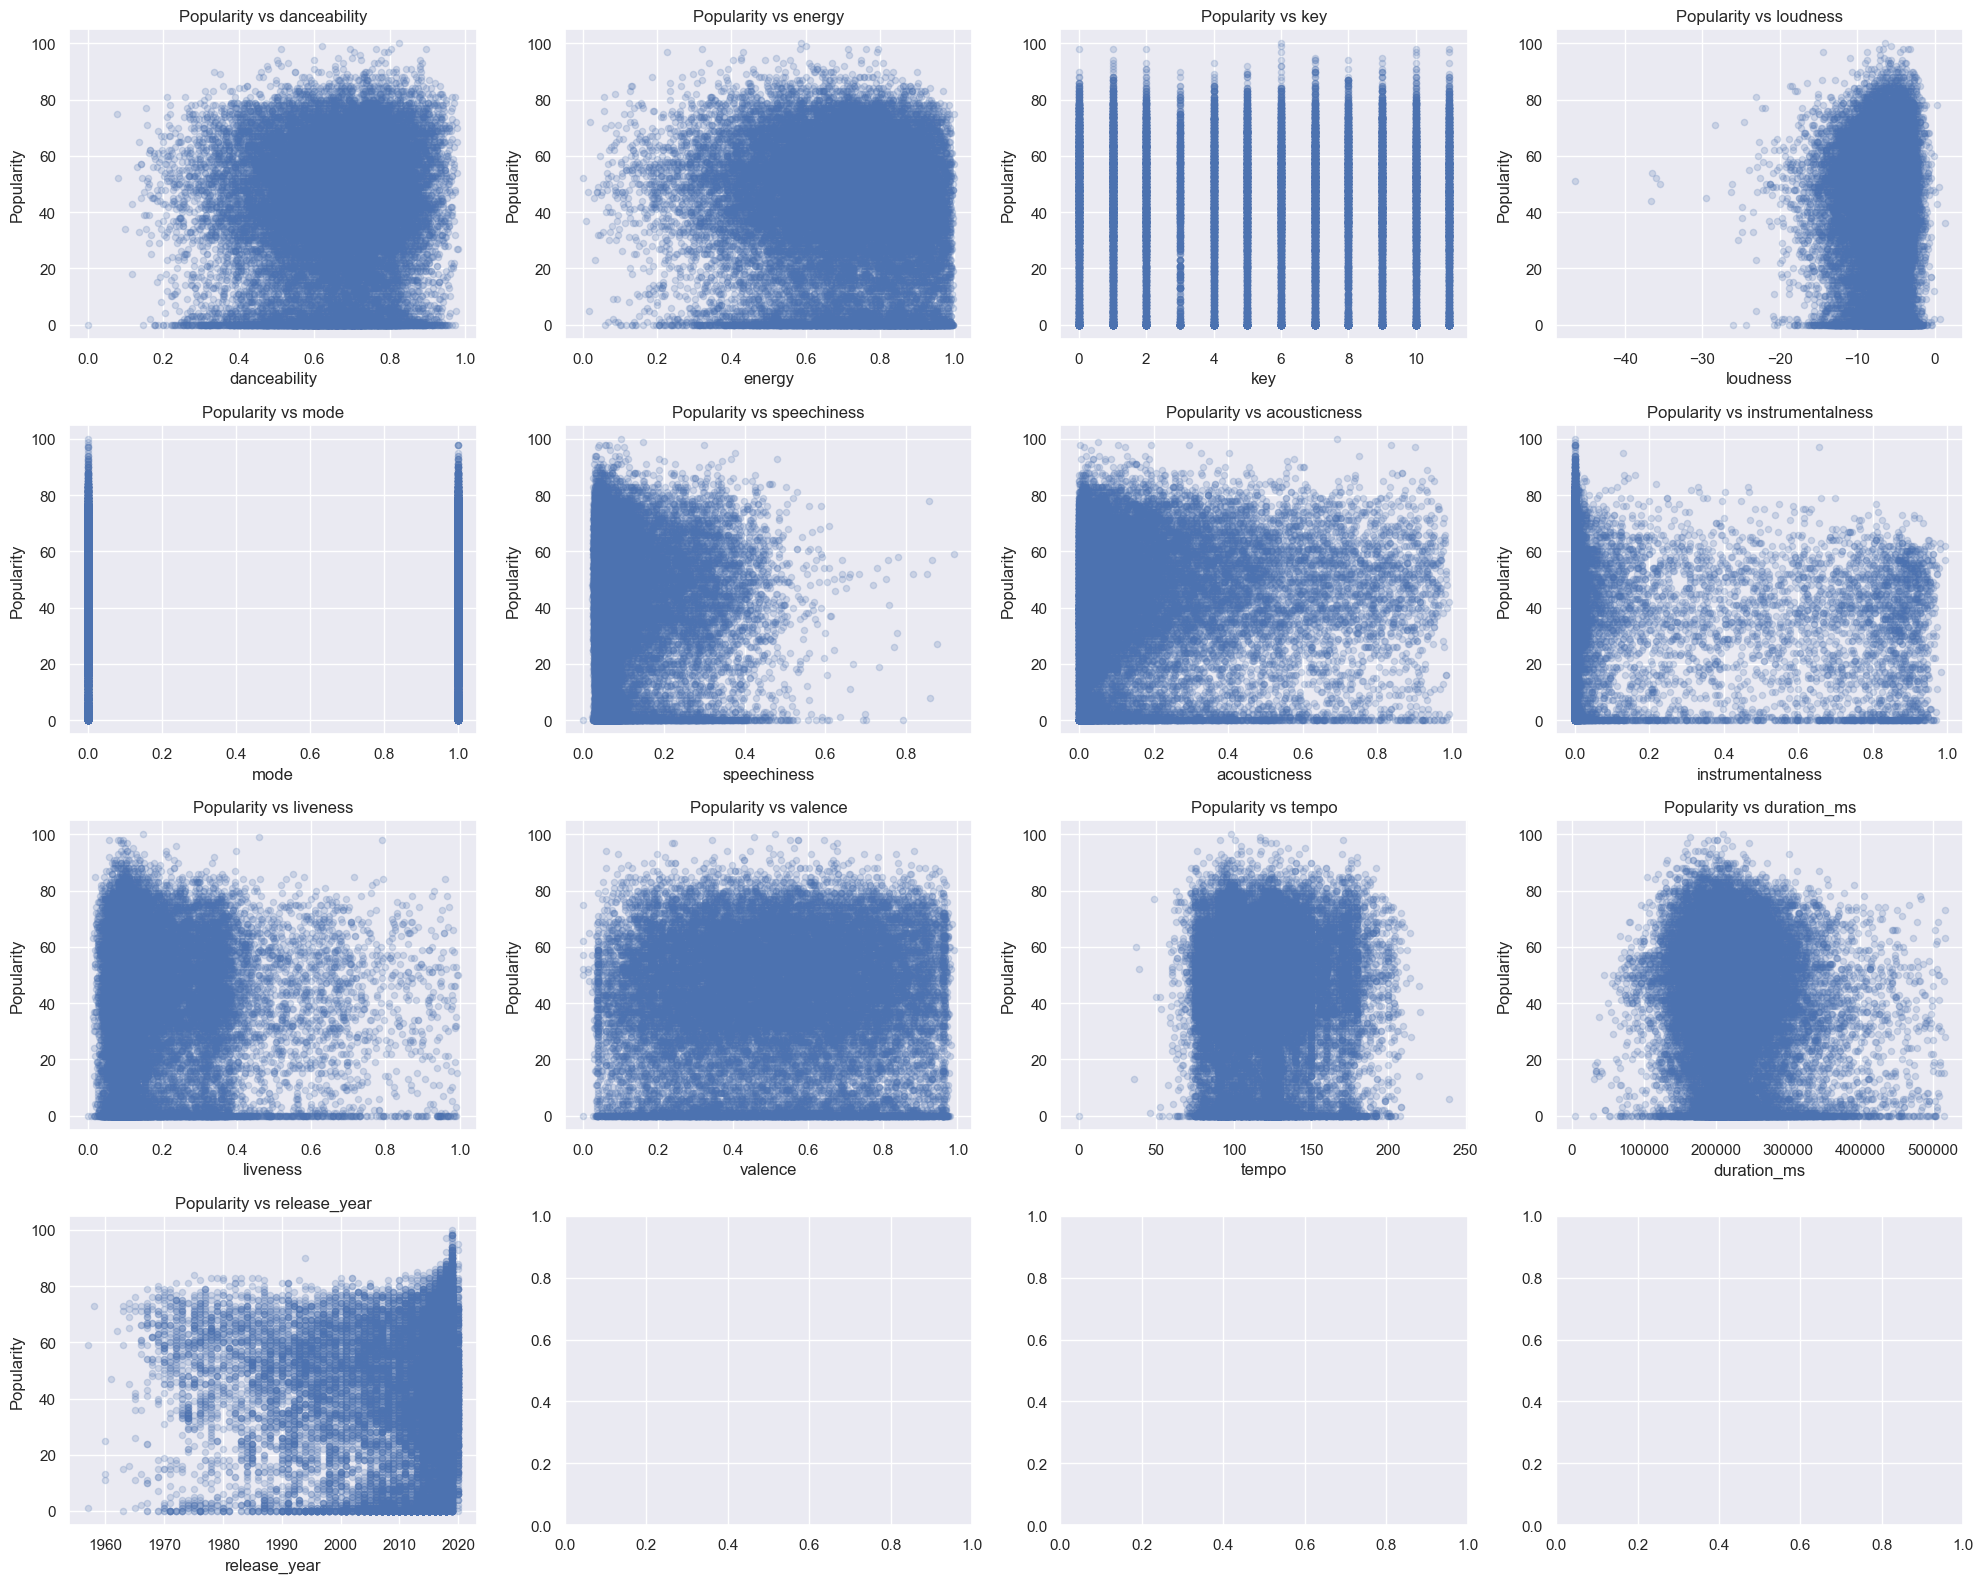

In [25]:
features_nopop = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
            'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'release_year']

n_features = len(features_nopop)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()  # flatten to easily iterate

for i, f in enumerate(features_nopop):
    axes[i].scatter(df[f], df['track_popularity'], alpha=0.2, s=20)
    axes[i].set_xlabel(f)
    axes[i].set_ylabel("Popularity")
    axes[i].set_title(f"Popularity vs {f}")

plt.tight_layout()
plt.show()

In [26]:
# Most popular tracks are from recent years, appear to have higher loudness, and lower liveness

# Export Dataset

In [27]:
# save the data to a new csv file
filepath = '..\Data\spotify_songs_cleaned2.csv'
df_cleaned.to_csv(filepath, index=False)

# Summary
<br>-Removed 1 track due to missing values and duration of 4 seconds
<br>-Popular tracks are from more recent years which are 2016-2020 (when the data was pulled)
<br>-Billie Ellish, Post Malone, and Ed Sheeran have the most tracks in the dataset
<br>-Examined ECDF to see distribution of feature values
<br>-Examined scatterplots to see relationship between popularity and each feature
